# ZipBench on MathVista_MINI (multimodal)

This notebook runs the full ZipBench compression pipeline on **MathVista_MINI**, a
multimodal benchmark with VLMEvalKit-style nested records and judge-scored xlsx files
(judge: `qwen3-30b`). We start from 6 real train models and 14 real
held-out test models over 1000 items, synthesize 6 extra train models by ensemble
voting, fit an IRT model, and compress the benchmark to weighted anchor subsets at
ratios 0.5 and 0.75.

## 1. Inspect the raw records

List the 6 real train models found under `train/` with their accuracies.

In [1]:
!python ../data_prep/vote_offline_results_xlsx_correctness.py \
  --root ../data/MathVista_MINI/train --dataset MathVista_MINI \
  --judge qwen3-30b --print-candidates

[INFO] No 'hit' column in Qwen3-VL-4B-Instruct_MathVista_MINI_qwen3-30b.xlsx; using MathVista res/answer_option correctness.
[INFO] No 'hit' column in Qwen3-VL-2B-Instruct_MathVista_MINI_qwen3-30b.xlsx; using MathVista res/answer_option correctness.
[INFO] No 'hit' column in Qwen2.5-VL-3B-Instruct_MathVista_MINI_qwen3-30b.xlsx; using MathVista res/answer_option correctness.
[INFO] No 'hit' column in Qwen2.5-VL-7B-Instruct_MathVista_MINI_qwen3-30b.xlsx; using MathVista res/answer_option correctness.
[INFO] No 'hit' column in Qwen3-VL-32B-Instruct_MathVista_MINI_qwen3-30b.xlsx; using MathVista res/answer_option correctness.
[INFO] No 'hit' column in GeminiPro3-1DMX_MathVista_MINI_qwen3-30b.xlsx; using MathVista res/answer_option correctness.
[INFO] Loaded 6 model result files. (missing=0, bad=0)
[INFO] Model performance summary:
  - 90_GeminiPro3-1DMX: accuracy=90.3000
  - 79_defaultQwen3-VL-32B-Instruct_full: accuracy=79.1000
  - 66.8_deepQwen2.5-VL-7B-Instruct_512: accuracy=67.0000
  -

## 2. Normalize the nested records

`prepare_nested_json_records.py` unifies each model's judged scoring file into a flat
`model/MathVista_MINI.json` staging directory; `--fallback-xlsx` converts from the
judged xlsx when no matching JSON exists. We normalize the train and test roots
separately.

In [2]:
!python ../data_prep/prepare_nested_json_records.py \
  ../data/MathVista_MINI/train ../data/MathVista_MINI/train_normalized \
  --dataset MathVista_MINI --judge qwen3-30b --fallback-xlsx --overwrite

Input root: ../data/MathVista_MINI/train
Output root: ../data/MathVista_MINI/train_normalized
Dataset file name: MathVista_MINI.json
judge: qwen3-30b
Mode: symlink; overwrite=True; dry_run=False; fallback_xlsx=True
[XLSX] 32_Qwen3-VL-4B-Instruct_128: ../data/MathVista_MINI/train/32_Qwen3-VL-4B-Instruct_128/Qwen3-VL-4B-Instruct/Qwen3-VL-4B-Instruct_MathVista_MINI_qwen3-30b.xlsx -> ../data/MathVista_MINI/train_normalized/32_Qwen3-VL-4B-Instruct_128/MathVista_MINI.json
[XLSX] 44.8_concise_Qwen3-VL-2B-Instruct_full: ../data/MathVista_MINI/train/44.8_concise_Qwen3-VL-2B-Instruct_full/Qwen3-VL-2B-Instruct/Qwen3-VL-2B-Instruct_MathVista_MINI_qwen3-30b.xlsx -> ../data/MathVista_MINI/train_normalized/44.8_concise_Qwen3-VL-2B-Instruct_full/MathVista_MINI.json
[XLSX] 56.1_deep_Qwen2.5-VL-3B-Instruct_256: ../data/MathVista_MINI/train/56.1_deep_Qwen2.5-VL-3B-Instruct_256/Qwen2.5-VL-3B-Instruct/Qwen2.5-VL-3B-Instruct_MathVista_MINI_qwen3-30b.xlsx -> ../data/MathVista_MINI/train_normalized/56.1_deep_

In [3]:
!python ../data_prep/prepare_nested_json_records.py \
  ../data/MathVista_MINI/testset ../data/MathVista_MINI/testset_normalized \
  --dataset MathVista_MINI --judge qwen3-30b --fallback-xlsx --overwrite

Input root: ../data/MathVista_MINI/testset
Output root: ../data/MathVista_MINI/testset_normalized
Dataset file name: MathVista_MINI.json
judge: qwen3-30b
Mode: symlink; overwrite=True; dry_run=False; fallback_xlsx=True
[XLSX] GeminiFlash3ThinkingDMX: ../data/MathVista_MINI/testset/GeminiFlash3ThinkingDMX/GeminiFlash3ThinkingDMX_MathVista_MINI_qwen3-30b.xlsx -> ../data/MathVista_MINI/testset_normalized/GeminiFlash3ThinkingDMX/MathVista_MINI.json
[XLSX] InternVL3_5-38B_full: ../data/MathVista_MINI/testset/InternVL3_5-38B_full/InternVL3_5-38B/InternVL3_5-38B_MathVista_MINI_qwen3-30b.xlsx -> ../data/MathVista_MINI/testset_normalized/InternVL3_5-38B_full/MathVista_MINI.json
[XLSX] InternVL3_5-8B_full: ../data/MathVista_MINI/testset/InternVL3_5-8B_full/InternVL3_5-8B/InternVL3_5-8B_MathVista_MINI_qwen3-30b.xlsx -> ../data/MathVista_MINI/testset_normalized/InternVL3_5-8B_full/MathVista_MINI.json
[XLSX] Qwen2.5-VL-3B-Instruct_full: ../data/MathVista_MINI/testset/Qwen2.5-VL-3B-Instruct_full/Qwe

## 3. Synthesize 6 training models

Uniform-accuracy-bin ensemble voting over the 6 real train models produces 6 synthetic
records (one per accuracy bin, ensembles of k >= 2 models). `--strict-bins` fails
loudly if any bin cannot be filled.

In [4]:
!python ../data_prep/batch_vote_uniform_bins_results_xlsx_correctness.py \
  --m 6 --root ../data/MathVista_MINI/train --dataset MathVista_MINI \
  --judge qwen3-30b --output-dir ../data/MathVista_MINI/synthetic_m6 \
  --strict-bins

[INFO] Global accuracy range (is_correct): [0.337000, 0.903000]
[INFO] Bin #000 [0.337000, 0.431333] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #001 [0.431333, 0.525667] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #002 [0.525667, 0.620000] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #003 [0.620000, 0.714333] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #004 [0.714333, 0.808667] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #005 [0.808667, 0.903000] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Candidate models available for voting: N=6; enumerating combinations with k=N..2 (desc).
[INFO] No 'hit' column in Qwen3-VL-4B-Instruct_MathVista_MINI_qwen3-30b.xlsx; using MathVista res/answer_option correctness.
[INFO] No 'hit' column in Qwen3-VL-2B

## 4. Reorganize the generated JSONs

Reshape the flat generated JSONs into the same `model/MathVista_MINI.json` layout as
the normalized real records.

In [5]:
!python ../data_prep/reorganize_json_files.py \
  ../data/MathVista_MINI/synthetic_m6/generated --dataset MathVista_MINI --no-confirm

JSON file reorganization script
Target directory: ../data/MathVista_MINI/synthetic_m6/generated
Target file name: MathVista_MINI.json
Dry run mode: no
Found 6 JSON file(s)

Processing: acc_0.815000_k_3_seed_40.json
  -> create folder: acc_0.815000_k_3_seed_40/
  -> move and rename to: acc_0.815000_k_3_seed_40/MathVista_MINI.json
  [OK] done

Processing: acc_0.397000_k_2_seed_42.json
  -> create folder: acc_0.397000_k_2_seed_42/
  -> move and rename to: acc_0.397000_k_2_seed_42/MathVista_MINI.json
  [OK] done

Processing: acc_0.726000_k_5_seed_5.json
  -> create folder: acc_0.726000_k_5_seed_5/
  -> move and rename to: acc_0.726000_k_5_seed_5/MathVista_MINI.json
  [OK] done

Processing: acc_0.599000_k_5_seed_1.json
  -> create folder: acc_0.599000_k_5_seed_1/
  -> move and rename to: acc_0.599000_k_5_seed_1/MathVista_MINI.json
  [OK] done

Processing: acc_0.518000_k_4_seed_7.json
  -> create folder: acc_0.518000_k_4_seed_7/
  -> move and rename to: acc_0.518000_k_4_seed_7/MathVista_MINI

## 5. Aggregate into train / test pkl

The train pkl merges the 6 normalized real models with the 6 synthetic models
(12 total); the test pkl aggregates the 14 normalized held-out models only.

In [6]:
!python ../data_prep/aggregate_results_json_multiqa.py \
  --root_dir ../data/MathVista_MINI/train_normalized ../data/MathVista_MINI/synthetic_m6/generated \
  --dataset_name MathVista_MINI \
  --output_path ../data/MathVista_MINI/MathVista_MINI_train.pkl

Processing file: ../data/MathVista_MINI/train_normalized/32_Qwen3-VL-4B-Instruct_128/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/train_normalized/44.8_concise_Qwen3-VL-2B-Instruct_full/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/train_normalized/56.1_deep_Qwen2.5-VL-3B-Instruct_256/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/train_normalized/66.8_deepQwen2.5-VL-7B-Instruct_512/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/train_normalized/79_defaultQwen3-VL-32B-Instruct_full/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/train_normalized/90_GeminiPro3-1DMX/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/synthetic_m6/generated/acc_0.397000_k_2_seed_42/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/synthetic_m6/generated/acc_0.518000_k_4_seed_7/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/synthetic_m6/generated/acc_0.599000_k_5_seed_1/MathVista_MINI.json
Processing file: ../

In [7]:
!python ../data_prep/aggregate_results_json_multiqa.py \
  --root_dir ../data/MathVista_MINI/testset_normalized \
  --dataset_name MathVista_MINI \
  --output_path ../data/MathVista_MINI/MathVista_MINI_test.pkl

Processing file: ../data/MathVista_MINI/testset_normalized/GeminiFlash3ThinkingDMX/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/testset_normalized/InternVL3_5-38B_full/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/testset_normalized/InternVL3_5-8B_full/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/testset_normalized/Qwen2.5-VL-3B-Instruct_full/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/testset_normalized/Qwen2.5-VL-7B-Instruct_full/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/testset_normalized/Qwen3-VL-235B-A22B-Instruct-API/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/testset_normalized/Qwen3-VL-2B-Instruct_full/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/testset_normalized/Qwen3-VL-32B-Instruct_full/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/testset_normalized/Qwen3-VL-4B-Instruct_full/MathVista_MINI.json
Processing file: ../data/MathVista_MINI/testset_normalize

## 6. Validate the pkl files

Expected: train (1000, 12), test (1000, 14), binary values, data key
`MathVista_MINI`.

In [8]:
import pickle, numpy as np

for name, path, n_models in [
    ("train", "../data/MathVista_MINI/MathVista_MINI_train.pkl", 12),
    ("test", "../data/MathVista_MINI/MathVista_MINI_test.pkl", 14),
]:
    with open(path, "rb") as f:
        d = pickle.load(f)
    corr = d["data"]["MathVista_MINI"]["correctness"]
    assert list(d["data"].keys()) == ["MathVista_MINI"]
    assert corr.shape == (1000, n_models), corr.shape
    assert len(d["models"]) == n_models
    assert set(np.unique(corr)) <= {0.0, 1.0}
    print(f"{name}: shape={corr.shape}, models={len(d['models'])}, "
          f"values={sorted(set(np.unique(corr)))}")

train: shape=(1000, 12), models=12, values=[0, 1]
test: shape=(1000, 14), models=14, values=[0, 1]


## 7. Train the IRT model

Fit a multidimensional 2PL IRT model (D=5, 2000 epochs, lr=0.1) on the 12-model train
matrix.

In [9]:
!python ../compression/train_irt.py --scenario MathVista_MINI \
  --train-pkl ../data/MathVista_MINI/MathVista_MINI_train.pkl \
  --output-dir ../output/MathVista_MINI --seed 7 --run-id 1 --device cuda

[19:35:31] config: model_type='multidim_2pl' epochs=2000              cli.py:109
           priors='hierarchical' initializers=[] dims=5 lr=0.1                  
           lr_decay=0.9999 dropout=0.5 hidden=100 vocab_size=None               
           log_every=200 seed=7 deterministic=True                              
           data_path:                                                 cli.py:111
           ../output/MathVista_MINI/irt_dataset_run1.jsonlines                  
           output directory: ../output/MathVista_MINI/irt_model_run1  cli.py:112
[19:35:31] amortized: False                                       dataset.py:112
[19:35:31] Vocab size: None                                       training.py:90
           Training Model...                                          cli.py:116
           args: {'device': 'cuda', 'num_items': 1000,           training.py:134
           'num_subjects': 12}                                                  

... [1357 lines omitted] ..

## 8. Compress at fixed ratios

K-means clustering on the IRT item parameters selects weighted anchor subsets. Ratio
is the fraction of items removed: 0.5 keeps ~500 items, 0.75 keeps ~250. Passing
`--test-data` also writes an evaluation JSON per ratio.

In [10]:
!python ../compression/compress_dataset.py --scenario MathVista_MINI \
  --train-data ../data/MathVista_MINI/MathVista_MINI_train.pkl \
  --model-path ../output/MathVista_MINI/irt_model_run1/ \
  --test-data ../data/MathVista_MINI/MathVista_MINI_test.pkl \
  --ratios 0.5 0.75 --seed 42 --output-dir ../compressed/MathVista_MINI


=== ratio 0.5 (seed=42) ===
Target anchors (approx): 500/1000 (ratio=0.5, subscenarios=1)
  - MathVista_MINI: items=1000, k=500
K-means clustering finished for scenario 'MathVista_MINI' (500/1000 items).
Anchor points saved to ../compressed/MathVista_MINI/MathVista_MINI_anchor_ratio_0p5.pkl
subset 500/1000 items, 14 models | MAE=0.00414 RMSE=0.00638 Spearman=1.0000 (p=0.00e+00)
Evaluation written to ../compressed/MathVista_MINI/MathVista_MINI_eval_ratio_0p5.json

=== ratio 0.75 (seed=42) ===
Target anchors (approx): 250/1000 (ratio=0.75, subscenarios=1)
  - MathVista_MINI: items=1000, k=250
K-means clustering finished for scenario 'MathVista_MINI' (250/1000 items).
Anchor points saved to ../compressed/MathVista_MINI/MathVista_MINI_anchor_ratio_0p75.pkl
subset 250/1000 items, 14 models | MAE=0.01143 RMSE=0.01406 Spearman=0.9868 (p=7.38e-11)
Evaluation written to ../compressed/MathVista_MINI/MathVista_MINI_eval_ratio_0p75.json


## 9. Results

For each ratio, compare every test model's weighted-anchor subset score against its
full-benchmark score (MAE / RMSE / Spearman rank correlation).

In [11]:
import json
import pandas as pd

rows, per_ratio = [], {}
for tag, ratio in [("0p5", 0.5), ("0p75", 0.75)]:
    with open(f"../compressed/MathVista_MINI/MathVista_MINI_eval_ratio_{tag}.json") as f:
        ev = json.load(f)
    rows.append({
        "ratio": ratio,
        "kept items": f"{ev['n_anchor_items']}/{ev['n_items_total']}",
        "MAE": round(ev["mae"], 5),
        "RMSE": round(ev["rmse"], 5),
        "Spearman": round(ev["spearman"]["coeff"], 4),
    })
    per_ratio[ratio] = ev

pd.DataFrame(rows)

,ratio,kept items,MAE,RMSE,Spearman
0,0.50,500/1000,0.00414,0.00638,1.0000
1,0.75,250/1000,0.01143,0.01406,0.9868


In [12]:
ev = per_ratio[0.75]
df = pd.DataFrame({
    "full": ev["full_accuracies"],
    "subset@0.5": {m: per_ratio[0.5]["subset_accuracies"][m] for m in ev["model_names"]},
    "subset@0.75": ev["subset_accuracies"],
}).sort_values("full", ascending=False)
df.round(4)

,full,subset@0.5,subset@0.75
Qwen3.5-VL-Plus-API,0.900,0.901,0.894
GeminiFlash3ThinkingDMX,0.888,0.889,0.894
doubao-seed-1-8,0.871,0.872,0.853
gpt-5.4,0.851,0.870,0.822
Qwen3-VL-Plus-API,0.847,0.848,0.852
Qwen3-VL-235B-A22B-Instruct-API,0.798,0.801,0.779
Qwen3-VL-32B-Instruct_full,0.792,0.793,0.793
InternVL3_5-38B_full,0.741,0.751,0.744
InternVL3_5-8B_full,0.717,0.712,0.713
Qwen2.5-VL-7B-Instruct_full,0.674,0.674,0.696


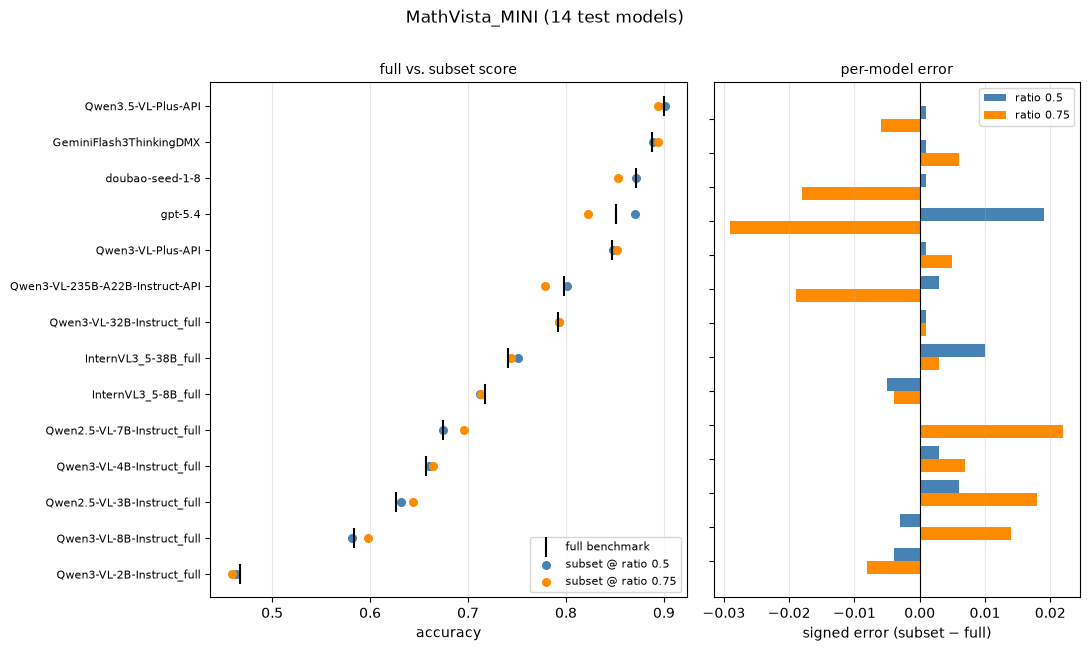

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Per-model view: full-benchmark score vs. weighted-anchor estimate, and the signed error per model.
models = list(df.index)  # already sorted by full score (descending)
y = np.arange(len(models))
colors = {0.5: "steelblue", 0.75: "darkorange"}

fig, (ax_score, ax_err) = plt.subplots(1, 2, figsize=(11, 0.35 * len(models) + 1.5),
                                       gridspec_kw={"width_ratios": [1.3, 1]})

ax_score.scatter(df["full"], y, color="k", marker="|", s=200, label="full benchmark", zorder=3)
for ratio, e in per_ratio.items():
    ax_score.scatter([e["subset_accuracies"][m] for m in models], y,
                     color=colors[ratio], s=30, label=f"subset @ ratio {ratio}")
ax_score.set_yticks(y); ax_score.set_yticklabels(models, fontsize=8); ax_score.invert_yaxis()
ax_score.set_xlabel("accuracy"); ax_score.grid(axis="x", alpha=0.3)
ax_score.legend(fontsize=8, loc="lower right"); ax_score.set_title("full vs. subset score", fontsize=10)

h = 0.38
for k, (ratio, e) in enumerate(per_ratio.items()):
    ax_err.barh(y + (k - 0.5) * h, [e["per_model_errors"][m] for m in models],
                height=h, color=colors[ratio], label=f"ratio {ratio}")
ax_err.axvline(0, color="k", lw=0.8)
ax_err.set_yticks(y); ax_err.set_yticklabels([]); ax_err.invert_yaxis()
ax_err.set_xlabel("signed error (subset − full)"); ax_err.grid(axis="x", alpha=0.3)
ax_err.legend(fontsize=8); ax_err.set_title("per-model error", fontsize=10)

fig.suptitle(f"MathVista_MINI ({len(models)} test models)", y=1.01)
plt.tight_layout()
plt.show()